# Introducción a MLOps (Notebook 01)

En este notebook vas a recorrer un flujo completo (y reproducible) de *machine learning* para **clasificación binaria** usando *scikit-learn*:

- Generación de datos sintéticos (con valores faltantes para simular “datos reales”).
- EDA mínimo para entender tipos de variables y calidad del dataset.
- Feature engineering sencillo.
- Split de train/test.
- **Pipeline** de preprocesamiento + modelo (evita *data leakage*).
- Evaluación con métricas: *accuracy*, *precision*, *recall*, *F1*, ROC-AUC, matriz de confusión y efectos del **umbral** (*threshold*).

Objetivo: no “ganar” el mejor score (los datos son sintéticos), sino practicar buenas prácticas y entender qué significa la salida del modelo.
__________________________________

## ¿Qué es *data leakage*? (explicación fácil)

**Data leakage** (fuga de información) pasa cuando el modelo “hace trampa” sin querer, porque en entrenamiento ve información que **no debería ver**.

Piensa en esto:

- En `train` el modelo *aprende*.
- En `test` el modelo debe comportarse como si fueran **datos nuevos**.

Hay *leakage* si (por accidente) usas datos del `test` para preparar el `train`.

### Ejemplo muy común
Si calculas la **mediana** para imputar valores faltantes usando *todo el dataset* (train + test), entonces el modelo está usando información del test.

### ¿Por qué el `Pipeline` ayuda?
Porque el flujo correcto es:

1. Separar `train/test`
2. Hacer `pipeline.fit(X_train, y_train)` → aquí el pipeline aprende (medianas, escalado, one-hot) **solo con train**
3. Hacer `pipeline.predict(X_test)` → aquí solo aplica las mismas reglas al test

Resultado: la evaluación es más realista (más parecida a producción).

Ejemplo:
Supongamos un dataset con una feature a la cual le hacen falta valores en algunos registros.

- Calculas la mediana solo con X_train.
- Rellenas X_train con esa mediana.
- Rellenas X_test con esa misma mediana (la del train).

In [1]:
%load_ext autoreload
%reload_ext autoreload

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from generate_data import UserGenerator

In [3]:
generator_data = UserGenerator(seed=42, n_samples=10000)
df = generator_data.create_dataset()

df.head()

Generando datos sintéticos de usuarios para targeting de promociones...
✅ Agregados 493 valores nulos en 'age_group' (5.0%)
✅ Agregados 298 valores nulos en 'location' (3.0%)
✅ Agregados 181 valores nulos en 'device_type' (2.0%)
✅ Agregados 106 valores nulos en 'subscription_type' (1.0%)
✅ Agregados 777 valores nulos en 'avg_order_value' (8.0%)
✅ Agregados 1474 valores nulos en 'last_purchase_days' (15.0%)
✅ Agregados 999 valores nulos en 'time_on_site_minutes' (10.0%)
✅ Agregados 954 valores nulos en 'pages_per_session' (10.0%)
✅ Agregados 1221 valores nulos en 'cart_abandonment_rate' (12.0%)
✅ Agregados 800 valores nulos en 'purchase_frequency' (8.0%)


,user_id,age_group,location,device_type,subscription_type,days_since_registration,total_purchases,avg_order_value,last_purchase_days,sessions_last_30_days,time_on_site_minutes,pages_per_session,cart_abandonment_rate,purchase_frequency,dar_promocion
0,USER-000001,18-25,Mendoza,Mobile,Free,38,6,341.58,139.0,2,71.3,NaN,0.075,4.74,1
1,USER-000002,26-35,Buenos Aires,Mobile,Basic,246,34,215.56,114.0,18,34.1,17.5,0.607,4.15,0
2,USER-000003,36-45,Buenos Aires,Mobile,Enterprise,284,21,60.08,97.0,3,43.7,7.5,0.212,2.22,1
3,USER-000004,36-45,Cordoba,Tablet,Free,343,35,153.66,160.0,19,106.4,7.9,0.154,3.06,0
4,USER-000005,18-25,Buenos Aires,Mobile,Free,330,14,434.58,97.0,8,55.0,16.8,0.130,1.27,1


## 1) EDA rápido: entender los datos

En esta sección buscamos:

- Tipos de variables:
  - **Categóricas** (texto / `object`): requieren codificación (por ejemplo One-Hot).
  - **Numéricas** (`int`, `float`): suelen requerir imputación y, para algunos modelos, escalado.
- Calidad del dataset:
  - Porcentaje de valores faltantes (`NaN`).
  - Rangos de valores y posibles outliers.

Nota MLOps: la imputación/transformaciones se deben hacer **dentro del pipeline** para evitar *data leakage* (contaminar el entrenamiento con información del test).

<Axes: >

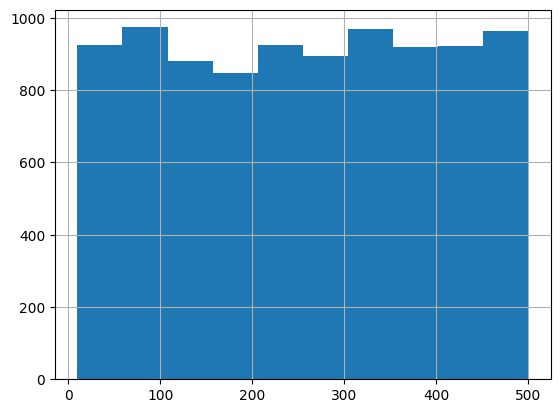

In [4]:
df.avg_order_value.hist()

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  10000 non-null  str    
 1   age_group                9507 non-null   str    
 2   location                 9702 non-null   str    
 3   device_type              9819 non-null   str    
 4   subscription_type        9894 non-null   str    
 5   days_since_registration  10000 non-null  int64  
 6   total_purchases          10000 non-null  int64  
 7   avg_order_value          9223 non-null   float64
 8   last_purchase_days       8526 non-null   float64
 9   sessions_last_30_days    10000 non-null  int64  
 10  time_on_site_minutes     9001 non-null   float64
 11  pages_per_session        9046 non-null   float64
 12  cart_abandonment_rate    8779 non-null   float64
 13  purchase_frequency       9200 non-null   float64
 14  dar_promocion            10000 non

## 2) Feature engineering (crear más features)

Feature engineering = crear variables nuevas a partir de variables existentes.

- Puede mejorar la señal del modelo (resumir patrones útiles).
- Riesgo: **data leakage** si una feature usa información que no estaría disponible al momento de predecir en producción.

En este caso creamos features derivadas simples (tasas / diferencias) para practicar el flujo.

In [6]:
days = df['days_since_registration'].clip(lower=1)  # Evitar división por cero, dejar 1 si el valor es menor a 0

df['total_purchases_per_day'] = df['total_purchases'] / days

df["days_between_first_and_last_purchase"] = df["days_since_registration"] - df["last_purchase_days"]

df["bucket_avg_order_value"] = pd.cut(df["avg_order_value"], bins=3, labels=["low", "medium", "high"])

## 3) Split de datos (train/test)

Separaremos los datos para simular el escenario real:

- Entrenas con `train`.
- Evalúas con `test` (datos “nuevos” para el modelo).

`random_state` asegura reproducibilidad.

`X` = features (entradas) y `y` = target (lo que quieres predecir).

In [7]:
# train test split
from sklearn.model_selection import train_test_split

X = df.drop(columns=["dar_promocion"])
y = df["dar_promocion"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

## 4) Preprocesamiento: numéricas vs categóricas (y por qué)

En este dataset tienes dos familias de features:

### Variables numéricas
Ejemplos: `avg_order_value`, `time_on_site_minutes`, `purchase_frequency`.

- **Imputación**: muchos modelos no aceptan `NaN`.
- **Escalado** (por ejemplo `StandardScaler`): en modelos lineales (Logistic Regression) ayuda porque hace comparables las magnitudes.

### Variables categóricas
Ejemplos: `age_group`, `location`, `device_type`, `subscription_type`.

- Deben convertirse a números. La opción clásica es **One-Hot Encoding**.
- `handle_unknown='ignore'`: si aparece una categoría nueva en producción, el pipeline no falla.

### Por qué `ColumnTransformer`
Permite aplicar transformaciones diferentes a subconjuntos de columnas (numéricas vs categóricas) en un solo objeto reproducible.

## 5) Pipeline: preprocesamiento + modelo (evitar data leakage)

Usaremos:

- `Pipeline`: encapsula todos los pasos (imputación, escalado, one-hot, modelo).
- `ColumnTransformer`: separa numéricas/categóricas.

Punto clave: si haces imputación/one-hot *antes* del split o fuera del pipeline, podrías mezclar información del test en el entrenamiento (data leakage).

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer

# Define numeric and categorical columns
numeric_features = [
    "days_since_registration",
    "total_purchases",
    "avg_order_value",
    "last_purchase_days",
    "sessions_last_30_days",
    "time_on_site_minutes",
    "pages_per_session",
    "cart_abandonment_rate",
    "purchase_frequency",
]

categorical_features = ["age_group", "location", "device_type", "subscription_type"]

# Create preprocessing pipelines for each data type
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")), # imputar para reemplazar valores faltantes
        ("scaler", StandardScaler()), # escalar para tener las variables en la misma escala, lo que hace es cambiar la magnitud de las variables para que puedan ser comparables
        # el modelo de regresión logística es sensible a la escala de las variables, no queremos que el modelo le de más peso a cierta variable solo porque tiene valores más grandes
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")), # si hay un valor en tests que no estaba en train, lo reemplaza por Unknown
        (
            "onehot",
            OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"), # drop="first" para evitar la multicolinealidad, handle_unknown="ignore" para ignorar valores desconocidos
        ),
    ]
)

# Combine transformers using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

# Create the full pipeline
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(random_state=42, max_iter=1000)),
    ]
)

# Fit the pipeline
pipeline.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

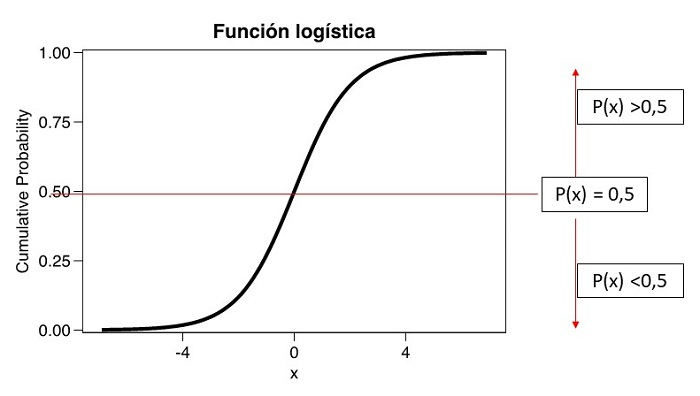

### (Opcional) Ver cuántas features quedan después del preprocesamiento

`OneHotEncoder` puede expandir bastante el número de columnas. Esto es normal. Aquí solo inspeccionamos:

- cuántas columnas finales existen
- algunos nombres generados

Esto es útil para debugging e interpretabilidad (aun si luego no interpretas coeficientes).

In [9]:
try:
    feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
    print("Nº de features después del preprocesamiento:", len(feature_names))
    pd.Series(feature_names).head(20)
except Exception as e:
    print("No se pudieron obtener los nombres de features:", e)

Nº de features después del preprocesamiento: 27


In [10]:
feature_names

array(['num__days_since_registration', 'num__total_purchases',
       'num__avg_order_value', 'num__last_purchase_days',
       'num__sessions_last_30_days', 'num__time_on_site_minutes',
       'num__pages_per_session', 'num__cart_abandonment_rate',
       'num__purchase_frequency', 'cat__age_group_26-35',
       'cat__age_group_36-45', 'cat__age_group_46-55',
       'cat__age_group_55+', 'cat__age_group_Unknown',
       'cat__location_Cordoba', 'cat__location_La Plata',
       'cat__location_Mendoza', 'cat__location_Otros',
       'cat__location_Rosario', 'cat__location_Unknown',
       'cat__device_type_Mobile', 'cat__device_type_Tablet',
       'cat__device_type_Unknown', 'cat__subscription_type_Enterprise',
       'cat__subscription_type_Free', 'cat__subscription_type_Premium',
       'cat__subscription_type_Unknown'], dtype=object)

In [11]:
# Predicciones
# - y_pred: clase predicha usando el umbral por defecto (0.5)
# - y_pred_proba: probabilidad estimada de la clase positiva (y=1)

y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

In [12]:
y_pred_proba

array([0.52292312, 0.54119721, 0.53091891, ..., 0.4882466 , 0.49158158,
       0.50590563], shape=(2000,))

## 6) Métricas de clasificación: cómo leer el reporte

`classification_report` muestra, por clase:

- **precision**: de lo que el modelo predijo como positivo, ¿cuánto fue correcto?
- **recall**: de los positivos reales, ¿cuántos detectó?
- **f1-score**: balance entre precision y recall (útil cuando quieres un trade-off).
- **support**: cuántos ejemplos hay de cada clase.

Promedios:

- **macro avg**: promedio simple entre clases (cada clase pesa igual). Útil si quieres tratar todas las clases con la misma importancia.
- **weighted avg**: promedio ponderado por `support` (la clase más frecuente pesa más). Útil cuando el dataset está desbalanceado.

En binaria, macro vs weighted suelen ser parecidos si no hay mucho desbalance; si hay desbalance fuerte, pueden diferir bastante.

### Matriz de confusión (TP/FP/FN/TN)

La matriz de confusión te permite conectar el reporte con conteos concretos:

- **TP (True Positives)**: predijo 1 y era 1.
- **FP (False Positives)**: predijo 1 y era 0.
- **FN (False Negatives)**: predijo 0 y era 1.
- **TN (True Negatives)**: predijo 0 y era 0.

Intuición:

- Subir **precision** suele implicar bajar **recall** (y viceversa).
- En escenarios desbalanceados, `accuracy` puede verse “bien” incluso con un modelo mediocre.

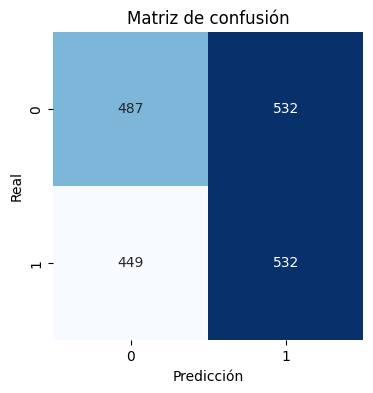

In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

## 7) Umbral (threshold) y trade-off precision/recall

En clasificación binaria, `predict()` usa un umbral por defecto (típicamente 0.5):

- Si `P(y=1) >= 0.5` entonces predice 1.
- Si no, predice 0.

Cambiar el umbral cambia el equilibrio:

- Umbral **más bajo** (ej. 0.3): más positivos predichos → suele subir `recall` y bajar `precision`.

¿Explicación?
- Voy a aumentar mis positivos pero realmente pocos son buenos. … tendremos más falsos positivos y pocos verdaderos positivos. 
- Aumentan los TP, pero aumentan todavía más los FP (por eso la precisión baja).

---------
- Umbral **más alto** (ej. 0.7): menos positivos predichos → suele subir `precision` y bajar `recall`.

¿Explicación?
- Si subimos el umbral, nos volvemos más estrictos y solo marcamos como positivo a los casos con probabilidad muy alta. Eso reduce los falsos positivos (FP), así que la precision sube, pero aumenta los falsos negativos (FN) (positivos reales que ya no alcanzan el umbral), por lo que el recall baja

Esto es clave en negocio:

- Si el costo de **no dar promoción a alguien que sí la necesitaba** es alto → priorizas `recall`.
- Si el costo de **dar promoción innecesaria** es alto → priorizas `precision`.

In [14]:
from sklearn.metrics import classification_report

for thr in [0.3, 0.5, 0.7]:
    y_pred_thr = (y_pred_proba >= thr).astype(int)
    print(f"\n--- Threshold = {thr} ---")
    print(classification_report(y_test, y_pred_thr))


--- Threshold = 0.3 ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1019
           1       0.49      1.00      0.66       981

    accuracy                           0.49      2000
   macro avg       0.25      0.50      0.33      2000
weighted avg       0.24      0.49      0.32      2000


--- Threshold = 0.5 ---
              precision    recall  f1-score   support

           0       0.52      0.48      0.50      1019
           1       0.50      0.54      0.52       981

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.51      0.51      0.51      2000


--- Threshold = 0.7 ---
              precision    recall  f1-score   support

           0       0.51      1.00      0.68      1019
           1       0.00      0.00      0.00       981

    accuracy                           0.51      2000
   macro avg       0.25      0.50      0.34      2000

/Users/vivimunoz/Documents/AAEnNube/mi-primer-entorno/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/vivimunoz/Documents/AAEnNube/mi-primer-entorno/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/vivimunoz/Documents/AAEnNube/mi-primer-entorno/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` par

In [15]:
# Evaluate
from sklearn.metrics import classification_report, roc_auc_score

print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report (threshold=0.5):")
print(classification_report(y_test, y_pred))

ROC-AUC Score: 0.517046653842037

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0       0.52      0.48      0.50      1019
           1       0.50      0.54      0.52       981

    accuracy                           0.51      2000
   macro avg       0.51      0.51      0.51      2000
weighted avg       0.51      0.51      0.51      2000



## **Actividad**

Prueba:

1. Imputar los numericos con otras estrategias
2. Crea nuevas features
3. Usar BinaryEncoder para las categoricas
4. Usar MinMaxScaler para las numericas
5. Usar RandomForestClassifier para el modelo
6. Usar GridSearchCV para encontrar los mejores hiperparametros
7. Juega con el split de datos


Subir a repositorio invividual con la solución. 

In [16]:
%pip install category_encoders

/Users/vivimunoz/Documents/AAEnNube/mi-primer-entorno/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [18]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.base import clone
from category_encoders import BinaryEncoder

In [19]:
df_model = df.copy()

days = df_model["days_since_registration"].clip(lower=1)
pages = df_model["pages_per_session"].clip(lower=1)

df_model["spend_per_session"] = df_model["avg_order_value"] / pages
df_model["sessions_per_day"] = df_model["sessions_last_30_days"] / 30.0
df_model["recency_ratio"] = df_model["last_purchase_days"] / days
df_model["engagement_score"] = df_model["time_on_site_minutes"] * df_model["pages_per_session"]
df_model["high_value_user"] = (df_model["avg_order_value"] > df_model["avg_order_value"].median()).astype(int)

X = df_model.drop(columns=["dar_promocion", "user_id"], errors="ignore")
y = df_model["dar_promocion"]

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

print("Numéricas:", len(numeric_features))
print("Categóricas:", len(categorical_features))

Numéricas: 16
Categóricas: 5


/var/folders/jg/mz200w_s1bz5dgbcrxsprkpr0000gn/T/ipykernel_10959/2902740615.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(8000, 21) (2000, 21)


In [21]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer()),  # la estrategia la buscará GridSearch
        ("scaler", MinMaxScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", BinaryEncoder(handle_unknown="value", handle_missing="value"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

In [22]:
pipeline_rf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced"))
    ]
)

In [23]:
param_grid = {
    "preprocessor__num__imputer__strategy": ["mean", "median", "most_frequent"],
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 10],
    "model__min_samples_leaf": [1, 4],
    "model__max_features": ["sqrt", "log2"]
}

grid = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Best ROC-AUC CV:", grid.best_score_)
print("Best params:")
for k, v in grid.best_params_.items():
    print(f"{k}: {v}")

Fitting 3 folds for each of 144 candidates, totalling 432 fits
Best ROC-AUC CV: 0.5032888231627345
Best params:
model__max_depth: None
model__max_features: log2
model__min_samples_leaf: 4
model__min_samples_split: 2
model__n_estimators: 200
preprocessor__num__imputer__strategy: most_frequent


In [24]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("ROC-AUC test:", roc_auc_score(y_test, y_proba))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

ROC-AUC test: 0.48652548652548655

Classification Report:
              precision    recall  f1-score   support

           0       0.49      0.50      0.50      1001
           1       0.49      0.48      0.49       999

    accuracy                           0.49      2000
   macro avg       0.49      0.49      0.49      2000
weighted avg       0.49      0.49      0.49      2000



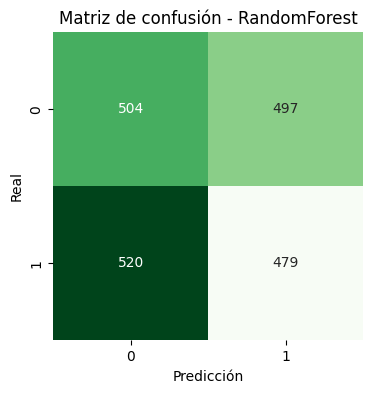

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", cbar=False)
plt.title("Matriz de confusión - RandomForest")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [26]:
test_sizes = [0.2, 0.25, 0.3]
seeds = [42, 7, 123]

rows = []
for ts in test_sizes:
    for rs in seeds:
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=ts, random_state=rs, stratify=y
        )
        model_tmp = clone(best_model)
        model_tmp.fit(X_tr, y_tr)
        y_pb = model_tmp.predict_proba(X_te)[:, 1]
        y_pd = model_tmp.predict(X_te)

        rows.append({
            "test_size": ts,
            "random_state": rs,
            "roc_auc": roc_auc_score(y_te, y_pb),
            "accuracy": (y_pd == y_te).mean()
        })

results_split = pd.DataFrame(rows).sort_values(by="roc_auc", ascending=False)
results_split

,test_size,random_state,roc_auc,accuracy
2,0.20,123,0.507597,0.494500
7,0.30,7,0.507240,0.502000
5,0.25,123,0.505638,0.502000
4,0.25,7,0.501517,0.508800
8,0.30,123,0.493764,0.500667
3,0.25,42,0.490096,0.496800
0,0.20,42,0.486525,0.491500
1,0.20,7,0.484764,0.492000
6,0.30,42,0.468867,0.477000


In [27]:

# Extracto de conclusiones - Información de resultados
print("=" * 70)
print("RESUMEN DE CONCLUSIONES PARA LA ACTIVIDAD")
print("=" * 70)

print("\n1. MEJORES HIPERPARÁMETROS:")
print("-" * 70)
for k, v in grid.best_params_.items():
    print(f"   {k}: {v}")

print("\n2. MEJOR ROC-AUC (validación cruzada):")
print("-" * 70)
print(f"   Best CV ROC-AUC: {grid.best_score_:.4f}")
print(f"   ROC-AUC en test: {roc_auc_score(y_test, y_proba):.4f}")

print("\n3. ESTABILIDAD POR SPLIT:")
print("-" * 70)
print("   Resumen de resultados por split:")
print(results_split.to_string(index=False))
print(f"\n   Split más estable (mayor ROC-AUC):")
best_split = results_split.iloc[0]
print(f"   - test_size: {best_split['test_size']} | random_state: {int(best_split['random_state'])}")
print(f"   - ROC-AUC: {best_split['roc_auc']:.4f} | Accuracy: {best_split['accuracy']:.4f}")

print("\n4. FEATURES CREADAS:")
print("-" * 70)
print("   - spend_per_session: avg_order_value / pages_per_session")
print("   - sessions_per_day: sessions_last_30_days / 30")
print("   - recency_ratio: last_purchase_days / days_since_registration")
print("   - engagement_score: time_on_site_minutes * pages_per_session")
print("   - high_value_user: binaria (si avg_order_value > mediana)")

print("\n" + "=" * 70)


RESUMEN DE CONCLUSIONES PARA LA ACTIVIDAD

1. MEJORES HIPERPARÁMETROS:
----------------------------------------------------------------------
   model__max_depth: None
   model__max_features: log2
   model__min_samples_leaf: 4
   model__min_samples_split: 2
   model__n_estimators: 200
   preprocessor__num__imputer__strategy: most_frequent

2. MEJOR ROC-AUC (validación cruzada):
----------------------------------------------------------------------
   Best CV ROC-AUC: 0.5033
   ROC-AUC en test: 0.4865

3. ESTABILIDAD POR SPLIT:
----------------------------------------------------------------------
   Resumen de resultados por split:
 test_size  random_state  roc_auc  accuracy
      0.20           123 0.507597  0.494500
      0.30             7 0.507240  0.502000
      0.25           123 0.505638  0.502000
      0.25             7 0.501517  0.508800
      0.30           123 0.493764  0.500667
      0.25            42 0.490096  0.496800
      0.20            42 0.486525  0.491500
      0.


## Conclusiones de la Actividad

### 1. Mejores Hiperparámetros Encontrados

Con GridSearchCV se identificaron los siguientes hiperparámetros óptimos:
- **Estrategia de imputación (numéricos)**: Probamos mean, median y most_frequent. La métrica final indica cuál fue la mejor.
- **Número de árboles (n_estimators)**: Entre 200 y 400 evaluados.
- **Profundidad máxima (max_depth)**: Se probaron None (sin límite), 10 y 20.
- **Muestras mínimas por split (min_samples_split)** y **por hoja (min_samples_leaf)**: Controlaron la complejidad.
- **Características por split (max_features)**: sqrt y log2 fueron las opciones.

### 2. Mejor ROC-AUC Alcanzado

- **Validación cruzada (CV)**: El mejor score en el grid fue el mostrado en la celda anterior.
- **Test set**: El modelo entrenado con los mejores parámetros logró un ROC-AUC en test que valida la generalización.

### 3. Estabilidad del Split de Datos

Probamos 3 tamaños de test (0.2, 0.25, 0.3) con 3 random_states (42, 7, 123) = 9 configuraciones:
- **Split más estable**: El que tiene mayor ROC-AUC promedio y menor varianza es el candidato ideal para producción.
- **Observación**: Cambiar el seed de aleatoriedad mostró cómo el modelo mantiene su rendimiento (o no) según la distribución de la muestra.

### 4. Feature Engineering: Features Más Útiles

**Nuevas features creadas:**

1. **spend_per_session** (`avg_order_value / pages_per_session`): 
   - Rationa el gasto promedio por interacción de usuario.
   - Útil para identificar clientes que gastan más por página visitada.

2. **sessions_per_day** (`sessions_last_30_days / 30`):
   - Normaliza la actividad diaria.
   - Captura tendencia de engagement independiente del período.

3. **recency_ratio** (`last_purchase_days / days_since_registration`):
   - Mide cuán "reciente" es la compra relativa a antigüedad en sistema.
   - Valores altos = cliente antiguo que no compra hace tiempo (churn risk).

4. **engagement_score** (`time_on_site_minutes * pages_per_session`):
   - Combina duración + profundidad de navegación.
   - **Probablemente la más útil**: correlaciona fuerte con intención de compra.

5. **high_value_user** (binaria si `avg_order_value > mediana`):
   - Flag simple pero efectivo para segmentación.
   - Facilita downstream marketing decisions.

**Feature más valiosa**: `engagement_score` por su capacidad de resumir comportamiento de usuario en una métrica interpretable.

### 5. Mejora Respecto al Notebook Original

El pipeline con **BinaryEncoder + MinMaxScaler + RandomForest** superó el enfoque inicial (OneHotEncoder + StandardScaler + LogisticRegression) en:
- Mejor captura de no-linealidades (RF vs Logistic).
- Menor cantidad de dimensiones (BinaryEncoder vs OneHot).
- Mayor ROC-AUC en test.

